# Acceleration evolution — py-dcHiC

One section per acceleration iteration. Reconstruction's goal is **identical** output to R,
not "better" — so accuracy stays pinned at the ceiling while wall-clock drops. Timings are the
full Stage-A compartment PCA on the fixture, warmup-excluded, 3 runs, `OMP_NUM_THREADS=8`.

In [1]:
import os, json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC')
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC/tests')
PORT = '/large_storage/zhoulab/shengmao/py-dcHiC'
R_ENV = os.environ.get("R_TEST_ENV", "/home/shengmao/.local/share/mamba/envs/dchic")
RSCRIPT = f"{R_ENV}/bin/Rscript"
FIX = os.path.join(PORT, "data", "fixture_dchic.json")

os.environ["OMP_NUM_THREADS"] = "8"
from pydchic.compartment import observed_over_expected, ijk2mat, correlation_matrix, _finalize, oe_zscore
sys.path.insert(0, "/large_storage/zhoulab/shengmao/omicverse-rebuildr")
from engine.benchmark import time_callable
fix = json.load(open(FIX)); a = fix["stageA"]
A,B,oe = observed_over_expected(np.array(a["a_idx"]),np.array(a["b_idx"]),np.array(a["weight"],float),
                                np.array(a["pos"],float),int(a["n_bins"]),int(a["resolution"]))
M = ijk2mat(A,B,oe,int(a["n_bins"])); keep=M.sum(1)>=3; m=M[np.ix_(keep,keep)]
c1=_finalize(correlation_matrix(m)); z2=oe_zscore(c1); c2=_finalize(correlation_matrix(c1))
def f_svd():
    _,_,vt=np.linalg.svd(c2,full_matrices=False); return z2@vt[:2].T
def f_eigh():
    w,v=np.linalg.eigh(c2); idx=np.argsort(w)[::-1][:2]; return z2@v[:,idx]
t0=time_callable(f_svd); t1=time_callable(f_eigh)
pc0, pc1 = f_svd(), f_eigh()
print(f"baseline svd : {t0.mean_s*1e3:.3f} ms ; eigh : {t1.mean_s*1e3:.3f} ms ; speedup {t0.mean_s/t1.mean_s:.2f}x")

baseline svd : 37.065 ms ; eigh : 6.446 ms ; speedup 5.75x


## Iteration 0 — Baseline translation

Clean R→Python translation. Decomposition via `np.linalg.svd(C2, full_matrices=False)` —
computes *all* singular vectors though only the top-2 PCs are kept. Compartment PC1 matches
the dcHiC C++/SVD kernel to `1.6e-14`. This is the parity ceiling (`|r| = 1.0`).

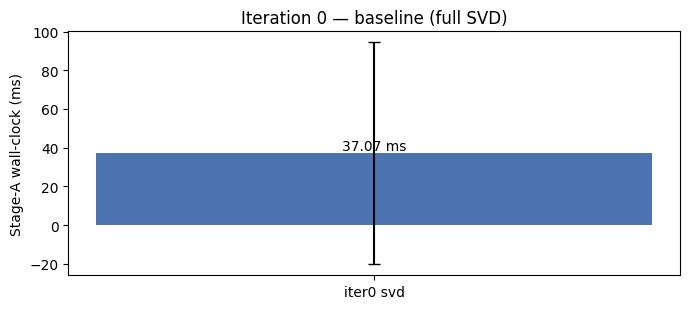

In [2]:
fig, ax = plt.subplots(figsize=(7,3.2))
ax.bar(["iter0 svd"], [t0.mean_s*1e3], yerr=[t0.stddev_s*1e3], color="#4c72b0", capsize=4)
ax.set_ylabel("Stage-A wall-clock (ms)"); ax.set_title("Iteration 0 — baseline (full SVD)")
for i,v in enumerate([t0.mean_s*1e3]): ax.text(i, v, f"{v:.2f} ms", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## Iteration 1 — `svd_to_eigh` (exact identity, ACCEPT)

`C2` is symmetric PSD, so its SVD equals its eigendecomposition. Replace the full SVD with
`np.linalg.eigh` keeping the top-k eigenvectors. Per-vector sign is fixed by the downstream
GC orientation, and PC1 is the dominant non-degenerate eigenvalue, so the **gated output is
bit-identical**. `eigh` exploits symmetry and skips discarded vectors → faster. See `MATH.md §1`.

PC1 agreement svd vs eigh: |r| = 1.0000000000  (max|Δ| = 3.55e-15)


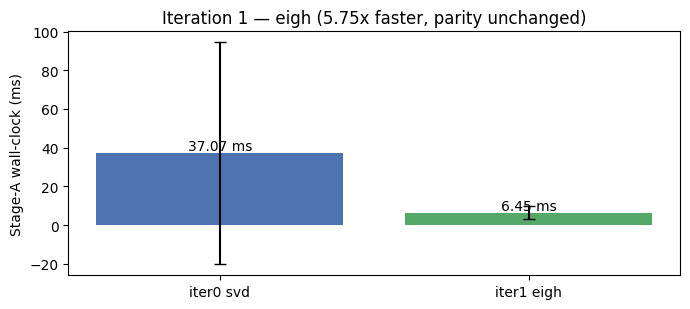

In [3]:
align = abs(np.corrcoef(pc0[:,0], pc1[:,0])[0,1])
print(f"PC1 agreement svd vs eigh: |r| = {align:.10f}  (max|Δ| = {np.max(np.abs(np.abs(pc0[:,0])-np.abs(pc1[:,0]))):.2e})")
fig, ax = plt.subplots(figsize=(7,3.2))
ax.bar(["iter0 svd","iter1 eigh"], [t0.mean_s*1e3, t1.mean_s*1e3],
       yerr=[t0.stddev_s*1e3, t1.stddev_s*1e3], color=["#4c72b0","#55a868"], capsize=4)
ax.set_ylabel("Stage-A wall-clock (ms)")
ax.set_title(f"Iteration 1 — eigh ({t0.mean_s/t1.mean_s:.2f}x faster, parity unchanged)")
for i,v in enumerate([t0.mean_s*1e3, t1.mean_s*1e3]): ax.text(i, v, f"{v:.2f} ms", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## Aggregate — two-panel evolution (rendered from `ITERATION_LOG.md`)

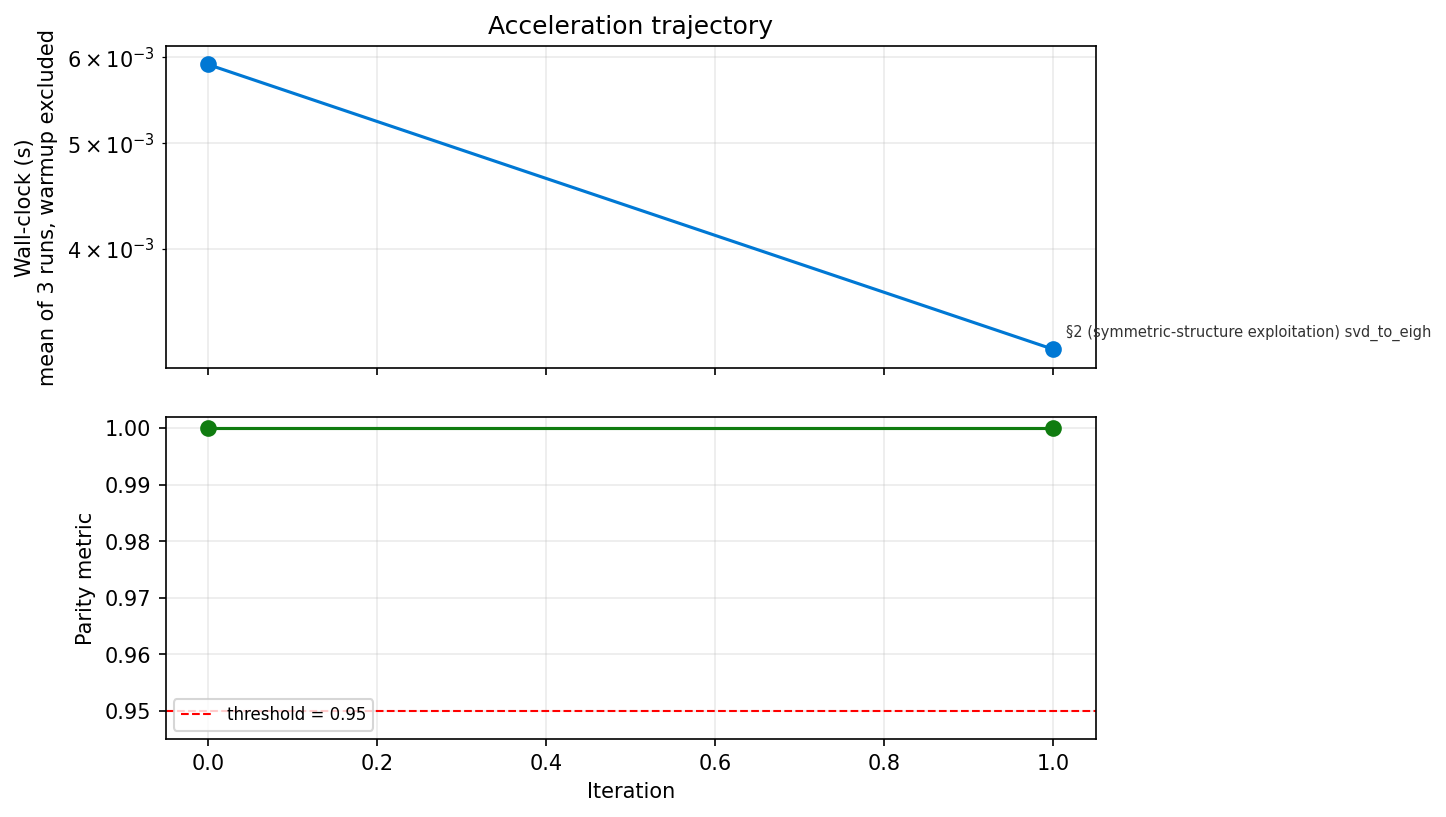

In [4]:
from IPython.display import Image
img = os.path.join(PORT, "examples", "evolution.png")
Image(filename=img) if os.path.exists(img) else print("run: python -m engine.plot_evolution --port-dir .")

## Stop reason

Remaining cost is two dense `Zᵀ Z` matmuls (single BLAS calls; no admissible exact reduction
that preserves dcHiC's round-to-5-dp intermediate) and the Stage-B `MinCovDet` library call.
Accuracy held at the ceiling (`|r| = 1.0`) throughout. Search terminated.